In [1]:
from matplotlib.colors import ListedColormap
import torch
import nrrd 
import matplotlib.pyplot as plt
import numpy as np
import torchvision.models as models 
from torch.utils.data import Dataset,DataLoader
from model.LeNet5 import LeNet
import numpy as np
import os
from PIL import Image, ImageOps
from torchvision import transforms
from pathlib import Path
from typing import Dict
import re
from torch.utils.data import random_split
from collections import Counter
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm
import torch.optim as optim
import wandb

In [2]:
#Global variable
pattern=re.compile(r"^Segment(\d+)_Tags$")
Segment_signal_string="Segmentation.Status:inprogress"
label_type={'Dut_hoan_toan_1_3_tren':1,
            'Dut_hoan_toan_1_3_duoi':2,
            'Dut_hoan_toan_1_3_giua':3,
            'Dut_ban_phan_1_3_tren':4,
            'Dut_ban_phan_1_3_duoi':5,
            'Dut_ban_phan_1_3_giua':6}

In [5]:
# seg,seg_header=nrrd.read(r"D:\personal_data\Duy Phan Ig\my_tool\Thanh dot 1\Le Van Chung_25938957\Segmentation.seg.nrrd")
# data_dict={k:v for k,v in seg_header.items() if k.startswith('Segment')}
# for i in range(len(data_dict)):
#     print(f"Key: {list(data_dict.keys())[i]}")
#     print(f"Value: {list(data_dict.values())[i]}")
#     print("=================================================")

In [8]:
from pathlib import Path
import nrrd
import pandas as pd

root_dir = Path(r'D:\Project\ACL\my_tool\data\2025_22_11_Thuan')

rows = []

for subfolder in root_dir.iterdir():

    if not subfolder.is_dir():
        continue

    # Find segmentation files
    seg_files = sorted(subfolder.glob("Segmentation*.seg.nrrd"))
    if not seg_files:
        continue

    # Find T2 files
    t2_files = sorted(
        p for p in subfolder.glob("*.nrrd")
        if "t2_tse_sag" in p.stem.lower()
    )
    if not t2_files:
        continue

    # Read files
    data, data_header = nrrd.read(t2_files[0])
    seg_data, seg_header = nrrd.read(seg_files[0])

    # Create row dictionary
    row = {"Patient_Name": subfolder.name}

    for k, v in seg_header.items():
        row[k] = v

    rows.append(row)

# Convert to DataFrame
df = pd.DataFrame(rows)

# Export CSV
output_path = root_dir / "segmentation_headers.csv"
df.to_csv(output_path, index=False)
print(f"CSV saved to: {output_path}")

CSV saved to: D:\Project\ACL\my_tool\data\2025_22_11_Thuan\segmentation_headers.csv


In [4]:
pattern_name=re.compile(r"^Segment(\d+)_Name$")
pattern_tags=re.compile(r"^Segment(\d+)_Tags$")
Segment_signal_string="Segmentation.Status:inprogress"

def get_tag_ACL(seg_header:Dict):
    seg_tags={k:v for k,v in seg_header.items() if ((m:=pattern_tags.match(k)) and (0<=int(m.group(1))<=5))}
    for i in range(len(seg_tags)):
        if list(seg_tags.values())[i].startswith(Segment_signal_string):
            return i 
        
def get_type_ACL(seg_header:Dict):
    tags=get_tag_ACL(seg_header)
    seg_names={k:v for k,v in seg_header.items() if ((m:=pattern_name.match(k)) and (0<=int(m.group(1))<=5))}
    name = seg_names[f"Segment{tags}_Name"]
    for i in range(len(label_type)):
        if name == list(label_type.keys())[i]:
            return list(label_type.values())[i]
    # for i in range(len(seg_names)):
    #     for j in range(len(label_type)):
    #         if (str(list(seg_names.values())[i])==str(list(label_type.keys())[j])):
    #             return list(label_type.values())[j]

def collect_data_and_seg(root_dir: str)->Dict:
    root_dir = Path(root_dir)
    result = {}
    for subfolder in root_dir.iterdir():
        if not subfolder.is_dir():
            continue
        # Find segmentation files
        seg_files = sorted(subfolder.glob("Segmentation*.seg.nrrd"))
        if not seg_files:
            continue
        # Find T2 files
        t2_files = sorted(
            p for p in subfolder.glob("*.nrrd")
            if "t2_tse_sag" in p.stem.lower()
        )
        if not t2_files:
            continue
        data,data_header=nrrd.read(t2_files[0])
        seg_data,seg_header=nrrd.read(seg_files[0])
        for key, value in seg_header.items():
            print(f"Key: {key}\n Value:{value}")
        type_acl=get_type_ACL(seg_header)
        result[subfolder.name] = {
            "nrrd": data,
            "seg": seg_data,
            "type":type_acl
        }
    return result

root_dir=r"D:\Project\ACL\my_tool\data\2025_22_11_Thuan"
data_dict=collect_data_and_seg(root_dir)
print(f"number of selected files: {len(data_dict)}")
for patient, data in data_dict.items():
    print(f"Patient {patient} with ACL type: {data['type']} ")



Key: type
 Value:unsigned char
Key: dimension
 Value:3
Key: space
 Value:left-posterior-superior
Key: sizes
 Value:[544 544  29]
Key: space directions
 Value:[[-0.0554808   0.2881645  -0.0194399 ]
 [-0.01731076 -0.02307751 -0.2926817 ]
 [-3.234925   -0.60668571  0.23916786]]
Key: kinds
 Value:['domain', 'domain', 'domain']
Key: encoding
 Value:gzip
Key: space origin
 Value:[ 43.5711 -84.5178  70.6235]
Key: Segment0_Color
 Value:0.501961 0.682353 0.501961
Key: Segment0_ColorAutoGenerated
 Value:1
Key: Segment0_Extent
 Value:235 334 218 316 16 17
Key: Segment0_ID
 Value:2.25.4027062157554748894172976553134323870
Key: Segment0_LabelValue
 Value:1
Key: Segment0_Layer
 Value:0
Key: Segment0_Name
 Value:Dut_hoan_toan_1_3_tren
Key: Segment0_NameAutoGenerated
 Value:0
Key: Segment0_Tags
 Value:TerminologyEntry:Segmentation category and type - 3D Slicer General Anatomy list~SCT^85756007^Tissue~SCT^85756007^Tissue~^^~Anatomic codes - DICOM master list~^^~^^|
Key: Segment1_Color
 Value:0.682353 0

In [7]:
class MRI_data(Dataset):
    def __init__(self,data_dict:Dict,img_trasform=None,label_transform=None,target_size=(320,320)):
        self.data_dict=data_dict
        self.img_transform=img_trasform
        self.label_transform=label_transform
        self.target_size=target_size
        self.samples=[]
        for patient, data in data_dict.items():
            nrrd_data=data['nrrd']
            seg_data=data['seg']
            type_acl=data['type']
            depth=nrrd_data.shape[2]
            for i in range(depth):
                img_slice=nrrd_data[:,:,i].astype(np.float32)
                seg_slice=seg_data[:,:,i]
                label = 0 if any(seg_slice.flatten())==False else type_acl+1
                self.samples.append((img_slice,label)) 
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, index): 
        img,label=self.samples[index]
        img=img/np.max(img)                         # Normalize to [0,1]
        img=torch.tensor(img,dtype=torch.float32)   # Convert to tensor
        img=img.unsqueeze(0)                        # Add channel dimension
        label=torch.tensor(label,dtype=torch.long)  # Convert label to tensor
        if self.img_transform:
            img=self.img_transform(img)
        if self.label_transform:
            label=self.label_transform(label)
        return img,label 

In [8]:
img_transform=transforms.Compose([
    transforms.Resize((320,320)),
])


In [9]:
dataset=MRI_data(data_dict=data_dict,img_trasform=img_transform)
print(f"Dataset length: {len(dataset)}")
print(f"Sample image shape: {dataset[39][0].shape}, Sample label: {dataset[39][1]}")



Dataset length: 497
Sample image shape: torch.Size([1, 320, 320]), Sample label: 0


In [10]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")

Training set size: 397
Validation set size: 100


Overall Dataset Label Distribution:


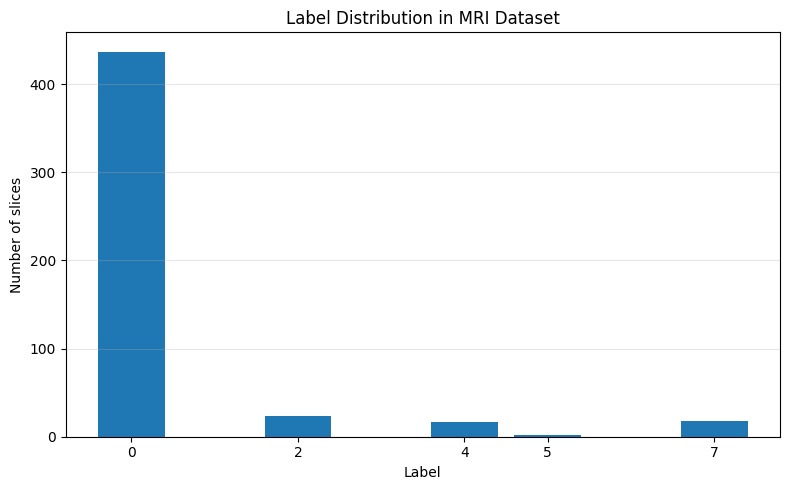

Label 0: 437 samples
Label 2: 23 samples
Label 4: 17 samples
Label 5: 2 samples
Label 7: 18 samples
Training Set Label Distribution:


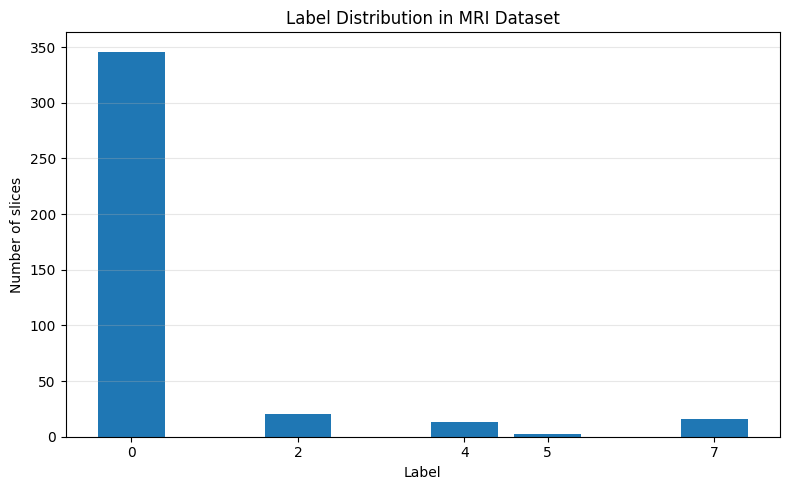

Label 0: 346 samples
Label 2: 20 samples
Label 4: 13 samples
Label 5: 2 samples
Label 7: 16 samples
Validation Set Label Distribution:


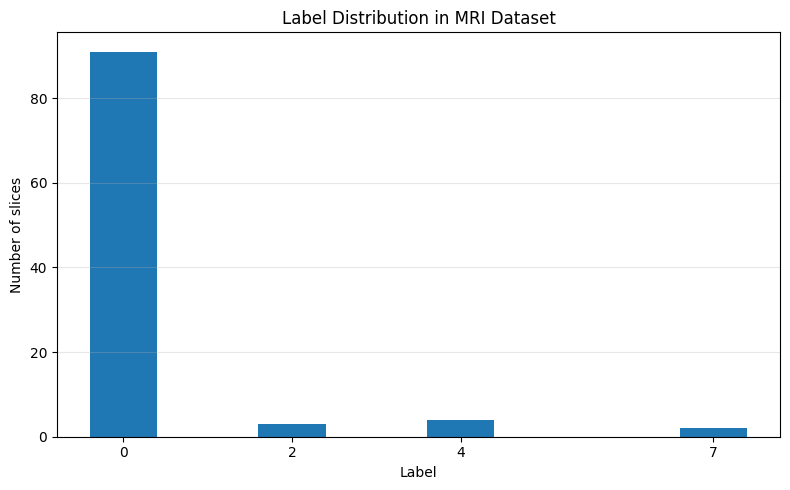

Label 0: 91 samples
Label 2: 3 samples
Label 4: 4 samples
Label 7: 2 samples


In [11]:
def plot_label_distribution(dataset):
    labels = []
    for _, label in dataset:
        # handle torch tensor labels
        if isinstance(label, torch.Tensor):
            label = label.item()
        labels.append(label)
    label_counts = Counter(labels)
    # sort by label index
    labels_sorted = sorted(label_counts.keys())
    counts_sorted = [label_counts[l] for l in labels_sorted]
    plt.figure(figsize=(8, 5))
    plt.bar(labels_sorted, counts_sorted)
    plt.xlabel("Label")
    plt.ylabel("Number of slices")
    plt.title("Label Distribution in MRI Dataset")
    plt.xticks(labels_sorted)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
    # also print counts
    for l in labels_sorted:
        print(f"Label {l}: {label_counts[l]} samples")
# Plot label distribution for the entire dataset, training set, and validation set
print("Overall Dataset Label Distribution:")
plot_label_distribution(dataset)
print("Training Set Label Distribution:")
plot_label_distribution(train_dataset)
print("Validation Set Label Distribution:")
plot_label_distribution(val_dataset)

In [12]:
target=[]
for _, label in train_dataset:
    if isinstance(label, torch.Tensor):
        label = label.item()
    target.append(label)
target=torch.tensor(target,dtype=torch.long)
# 1) unique classes
classes = torch.unique(target, sorted=True)
print(f"Unique classes in training set: {classes}")
# 2) mapping: label → index
class_to_index = {int(c): i for i, c in enumerate(classes)}
# 3) count samples per class
class_samples_count = torch.tensor([
    (target == c).sum() for c in classes
], dtype=torch.float)
# 4) class weights
weight = 1.0 / class_samples_count
# 5) sample weights (SAFE)
samples_weight = torch.tensor(
    [weight[class_to_index[int(t)]] for t in target],
    dtype=torch.float
)
# 6) sampler
sampler = torch.utils.data.WeightedRandomSampler(
    weights=samples_weight,
    num_samples=len(samples_weight),
    replacement=True
)


Unique classes in training set: tensor([0, 2, 4, 5, 7])


In [13]:
train_loader = DataLoader(train_dataset,batch_size=16,sampler=sampler,shuffle=False)
val_loader = DataLoader(val_dataset,batch_size=16,shuffle=True)

In [14]:
wandb.login()

wandb: Currently logged in as: baymaxnguyen306 (baymaxnguyen306-ho-chi-minh-city-university-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [12]:
ARCH={
    'cnn1':
    {
        'input_image_size': (320, 320),
        'input_channel': 1,
        'number_of_conv_layer':3,
        'number_of_fc_layer':2,
        'num_classes':7,
        'conv_channels': [6, 16,24],
        'fc_feature':[104,7]
    },
    'cnn2':
    {
        'input_image_size': (320, 320),
        'input_channel': 1,
        'number_of_conv_layer':4,
        'number_of_fc_layer':3,
        'num_classes':7,
        'conv_channels': [6, 16,24,32],
        'fc_feature':[104,64,7]
    }
}

In [13]:
class TrainerWB: 
    def __init__(self,config,train_loader,val_loader): 
        self.config=config
        self.device=torch.device('cuda' if torch.cuda.is_available() else'cpu')
        self.epochs=config.epoch
        self.learning_rate=config.lr
        self.batch_size=config.batch_size

        self.train_loader=train_loader
        self.val_loader=val_loader

        para=ARCH[config.architecture]
        self.model=LeNet(para).to(self.device)

        self.criterion=nn.CrossEntropyLoss()
        self.optimizer=self.optim_build()

        wandb.config.update({"model_para": para}, allow_val_change=True)

    def optim_build(self): 
        if self.config['optim']=='SGD': 
            return optim.SGD(self.model.parameters(), lr=self.learning_rate, momentum=0.9) 
        elif self.config['optim']=='Adam': 
            return optim.Adam(self.model.parameters(), lr=self.learning_rate) 
        else: 
            raise ValueError("Unsupported optimizer type") 
    def train(self): 
        self.model.train()
        running_loss=0.0 
        correct=9 
        total=0 
        loop=tqdm(self.train_loader,desc='Tao dang training',leave=False) 
        for image, label in loop: 
            image,label= image.to(self.device), label.to(self.device) 
            #Forward propagation: 
            output=self.model(image) 
            loss=self.criterion(output,label) 
            #backward propagation 
            self.optimizer.zero_grad() 
            loss.backward() 
            self.optimizer.step() 
            #Metrics calculation 
            running_loss += loss.item() 
            preds=torch.argmax(output,dim=1) 
            correct += (preds==label).sum().item() 
            total += label.size(0)
             #Update progress bar 
            loop.set_postfix(loss=running_loss/ (total/self.batch_size), accuracy=100.* correct/ total) 
        avg_loss = running_loss / total 
        accuracy = correct / total 
        return avg_loss, accuracy 
    def validate(self): 
        self.model.eval() 
        running_loss = 0.0 
        correct = 0 
        total = 0 
        with torch.no_grad(): 
            for images, labels in self.val_loader: 
                images, labels = images.to(self.device), labels.to(self.device) 
                outputs = self.model(images) 
                loss = self.criterion(outputs, labels) 
                running_loss += loss.item() * images.size(0) 
                preds = torch.argmax(outputs, dim=1) 
                correct += (preds == labels).sum().item() 
                total += labels.size(0) 
            avg_loss = running_loss / total 
            accuracy = correct / total 
        return avg_loss, accuracy 
    def fit(self): 
        for epoch in range(self.epochs): 
            train_loss, train_acc = self.train() 
            val_loss, val_acc = self.validate() 
            print(f"Epoch [{epoch+1}/{self.epochs}], Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}") 
            wandb.log({ "Train Loss": train_loss, 
                        "Train Accuracy": train_acc, 
                        "Validation Loss": val_loss, 
                        "Validation Accuracy": val_acc }) 
            print("Training complete.")

In [14]:
def main():
    with wandb.init(project="ACL_Classification", reinit=True):
        trainer = TrainerWB(
            config=wandb.config,
            train_loader=train_loader,
            val_loader=val_loader
        )
        trainer.fit()

In [15]:
sweep_config={
    'method':'random',
    'metric':{
        'name':'Validation Accuracy',
        'goal':'maximize'
    },
    'parameters':{
        'lr':{
            'values':[0.01,0.001,0.0001]
        },
        'epoch':{
            'values':[50,60,70]
        },
        'batch_size':{
            'values':[2,4,8,16]
        },
        'optim':{
            'values':['SGD']
        },
        'architecture':{
            'values':['cnn1','cnn2']
        }
    }
}

In [16]:
sweep_id= wandb.sweep(sweep_config, project="ACL_Classification")
wandb.agent(sweep_id, function=main, count=10)

Create sweep with ID: sstqt5db
Sweep URL: https://wandb.ai/baymaxnguyen306-ho-chi-minh-city-university-of-technology/ACL_Classification/sweeps/sstqt5db


wandb: Agent Starting Run: durzehck with config:
wandb: 	architecture: cnn1
wandb: 	batch_size: 8
wandb: 	epoch: 70
wandb: 	lr: 0.001
wandb: 	optim: SGD


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Epoch [1/70], Train Loss: 0.1058, Train Acc: 0.5793, Val Loss: 2.0035, Val Acc: 0.0400
Training complete.


Epoch [2/70], Train Loss: 0.0898, Train Acc: 0.7758, Val Loss: 1.9938, Val Acc: 0.1300
Training complete.


...

Epoch [57/60], Train Loss: 0.2007, Train Acc: 1.0227, Val Loss: 3.2922, Val Acc: 0.8900
Training complete.


Epoch [58/60], Train Loss: 0.2007, Train Acc: 1.0227, Val Loss: 3.2884, Val Acc: 0.9100
Training complete.


Epoch [59/60], Train Loss: 0.2007, Train Acc: 1.0227, Val Loss: 3.2927, Val Acc: 0.8900
Training complete.


Epoch [60/60], Train Loss: 0.2007, Train Acc: 1.0227, Val Loss: 3.2889, Val Acc: 0.9000
Training complete.


Train Accuracy,▁▂▆▆▆▆▇▇████████████████████████████████
Train Loss,█▇▆▄▃▂▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Validation Accuracy,▁▁▁▂▂▂▂▂▂▂██████████████████████████████
Validation Loss,██▇▇▇▇▇▇▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Train Accuracy,1.02267
Train Loss,0.20066
Validation Accuracy,0.9
Validation Loss,3.28888
